# Diff-In-Diff

Difference in Difference is a quasi-experimental design that makes use of longitudinal data from treatment and control groups to obtain an appropriate counterfactual to estimate a causal effect.

## Assumptions

* Treatment/intervention and control groups have **Parallel Trends** in outcome during pre-treatment period. This is often confirmed via visual inspection. 
* Intervention unrelated to outcome at baseline (allocation of intervention was not determined by outcome)
* Composition of intervention and comparison groups is stable for repeated cross-sectional design (part of SUTVA)
* No spillover effects (part of SUTVA)
    * SUTVA = Staple Unit Treatment Values. Simply put this means that units receiving treatment are only responding to its treatment, not the random assignment of others. 
    * In GeoX, this is assumed, but say if we target Geo's at the zip code level, you could argue that folks are traveling between zip codes and would violate this assumption. 

## Notes on implementation

* Our implementation requires a simultaneous adoptions i.e. treatment start at same time for all treated units. 

### Resources
* https://www.publichealth.columbia.edu/research/population-health-methods/difference-difference-estimation
* https://en.wikipedia.org/wiki/Difference_in_differences

In [1]:
import sys 

sys.path.insert(0, '../../')




In [2]:
import panel_exp


In [3]:
import scipy.stats as st
from dataclasses import dataclass

from matplotlib import pyplot as plt
from typing import Dict, Optional
from abc import (
  ABC,
  abstractmethod,
)

from __future__ import annotations

from panel_exp.methods.tbr import TBR
from panel_exp.methods.scm import SyntheticControl, AugSynth

from panel_exp.inference.unit_jackknife import unit_jk
import statsmodels.formula.api as smf

In [5]:
import numpy as np
import pandas as pd
from panel_exp.panel_data import long_df_to_paneldataset 
from panel_exp.methods.DID import DID

# California Smoking Dataset

In [6]:
long_df = pd.read_csv('../data/smoking.csv')

In [7]:
long_df


,Unnamed: 0,state,year,cigsale,lnincome,beer,age15to24,retprice
0,1,Rhode Island,1970,123.900002,NaN,NaN,0.183158,39.299999
1,2,Tennessee,1970,99.800003,NaN,NaN,0.178044,39.900002
2,3,Indiana,1970,134.600006,NaN,NaN,0.176516,30.600000
3,4,Nevada,1970,189.500000,NaN,NaN,0.161554,38.900002
4,5,Louisiana,1970,115.900002,NaN,NaN,0.185185,34.299999
...,...,...,...,...,...,...,...,...
1204,1205,New Mexico,2000,53.799999,NaN,NaN,NaN,279.799988
1205,1206,Connecticut,2000,71.400002,NaN,NaN,NaN,312.299988
1206,1207,Vermont,2000,88.900002,NaN,NaN,NaN,301.100006
1207,1208,Ohio,2000,99.900002,NaN,NaN,NaN,265.399994


In [8]:
long_df.columns = ['unnamed', 'unit', 'time_unit', 'y',  'lnincome','beer','age15to24','retprice']

In [9]:
panel_data = long_df_to_paneldataset(long_df, "time_unit", "unit", "y", ["California"], 1989)


In [10]:
panel_data.long_data

,unit,time_unit,value
0,Alabama,1970,89.800003
1,Arkansas,1970,100.300003
2,California,1970,123.000000
3,Colorado,1970,124.800003
4,Connecticut,1970,120.000000
...,...,...,...
1204,Vermont,2000,88.900002
1205,Virginia,2000,96.699997
1206,West Virginia,2000,107.900002
1207,Wisconsin,2000,80.099998


In [11]:
print(panel_data.summarize())


        Panel Dataset Summary
        ---------------------
        Number of time points: 31
        Number of units: 39
        Number of treated units: 1
        Treated units: ['California']
        Treated periods: [TimePeriod(start=1989, end=None)]
        


In [12]:
did = DID()

In [13]:
did.run_analysis(panel_data)

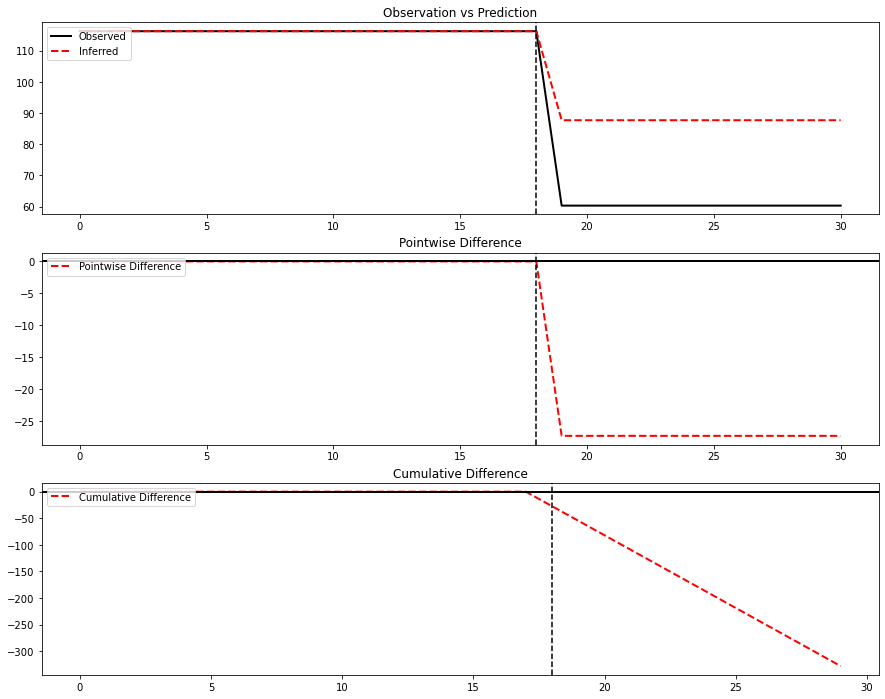

In [14]:
did.plot()

In [15]:
did.summary()

,Average,Cumulative
Actual,60.35,724.200001
Predicted,87.699111,1052.389334
,,
Absolute Effect,-27.349111,-328.189333
,,
Relative Effect,-31.185163,-31.185163


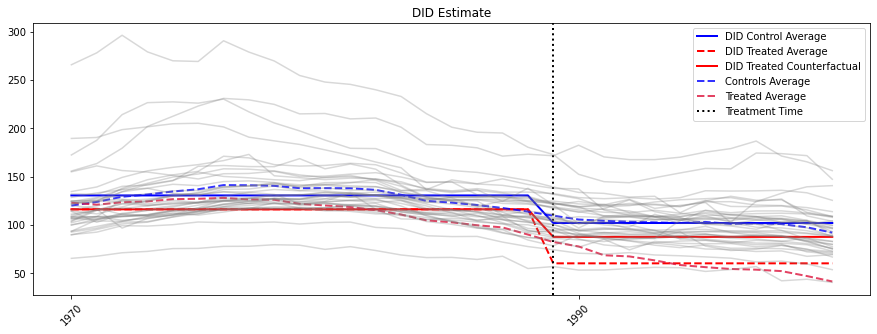

In [16]:
did.plot_2()

## Access P-Value
To get a p-value for DID, you can access the model summary, such as below, the post_treated_cross gives you both the ATT and the associated p-value along with other model summary information. 


In [17]:
did.model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  value   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     105.1
Date:                Fri, 10 Nov 2023   Prob (F-statistic):           1.99e-60
Time:                        09:48:53   Log-Likelihood:                -5793.3
No. Observations:                1209   AIC:                         1.159e+04
Df Residuals:                    1205   BIC:                         1.161e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            130.5695      1.087    120.112      0.000     128.437     132.702
treated              -14.3590      6.789     -2.115      0.035     -27.678      -1.040
post_treated         -28.5114      1.747    -16.318      0.000     -31.939     -25.084
post_treated_cross   -27.3491     10.911     -2.506      0.012     -48.756      -5.942
==============================================================================
Omnibus:                      470.050   Durbin-Watson:                   2.094
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2334.004
Skew:                           1.760   Prob(JB):                         0.00
Kurtosis:                       8.826   Cond. No.                         15.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Kansas Datasest

In [18]:
long_df = pd.read_csv('../data/kansas_parsed.csv')
long_df.head()

,Unnamed: 0,lngdp,treated,fips,year_qtr,state
0,1,11.178990,0,1,1990.00,Alabama
1,2,11.194348,0,1,1990.25,Alabama
2,3,11.209473,0,1,1990.50,Alabama
3,4,11.224373,0,1,1990.75,Alabama
4,5,11.239054,0,1,1991.00,Alabama


In [19]:
long_df.columns = ['un', 'value', 'treated', 'fips', 'time_unit', 'unit']

In [20]:
panel_data = long_df_to_paneldataset(long_df, "time_unit", "unit", "value", ["Kansas"], 2012)


In [21]:
panel_data.num_timepoints

105

In [22]:
print(panel_data.summarize())


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 50
        Number of treated units: 1
        Treated units: ['Kansas']
        Treated periods: [TimePeriod(start=2012, end=None)]
        


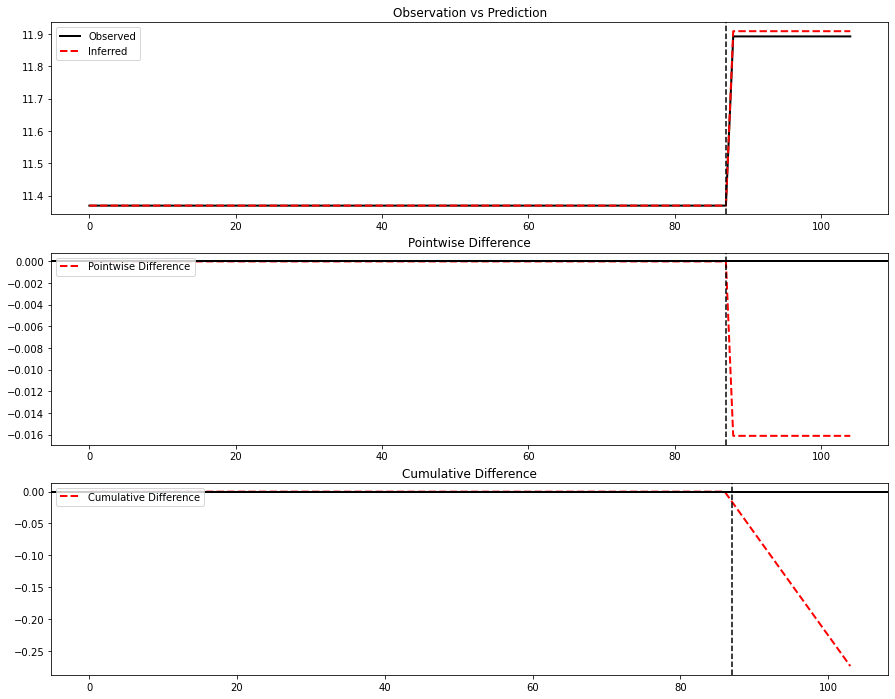

In [23]:
did = DID()
did.run_analysis(panel_data)
did.plot()

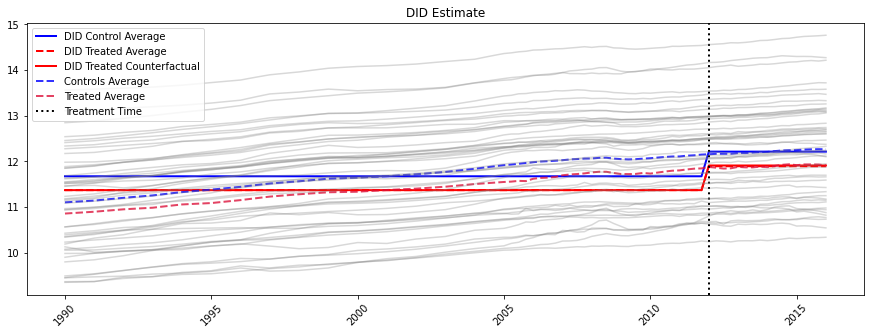

In [24]:
did.plot_2()

In [25]:
did.summary()

,Average,Cumulative
Actual,11.892406,202.170901
Predicted,11.908524,202.444911
,,
Absolute Effect,-0.016118,-0.274011
,,
Relative Effect,-0.135351,-0.135351


# Adobe Dataset

In [26]:
from panel_exp import panel_data

data = pd.read_csv('../data/ps_up.csv')[95:-8]

In [27]:
# make wide. Pre-Aggregate. 
data.index = data['date_date']
del data['date_date']
wide = data.T

In [28]:


treated_times = wide.columns[-52:-1]
treated_times = panel_data.TimePeriod(start=treated_times[0], end=treated_times[-1])
treated_units = ['test']
panel_d = panel_data.PanelDataset(wide, treated_times, treated_units)


In [29]:
panel_d.long_data.columns = ['unit', 'time_unit', 'value']

In [30]:
panel_d.long_data.columns

Index(['unit', 'time_unit', 'value'], dtype='object')

In [31]:
print(panel_d.summarize())



        Panel Dataset Summary
        ---------------------
        Number of time points: 165
        Number of units: 2
        Number of treated units: 1
        Treated units: ['test']
        Treated periods: [TimePeriod(start='2023-04-27', end='2023-06-16')]
        


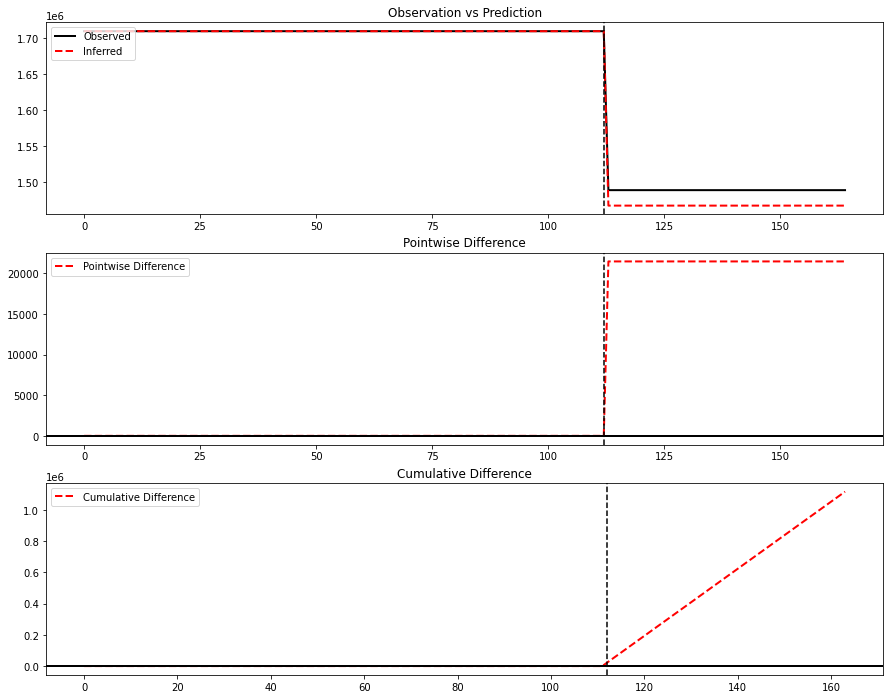

In [32]:
did = DID()
did.run_analysis(panel_d)
did.plot()

In [33]:
did.summary()

,Average,Cumulative
Actual,1489380.062725,77447763.2617
Predicted,1467917.81038,76331726.139771
,,
Absolute Effect,21462.252345,1116037.121929
,,
Relative Effect,1.462088,1.462088


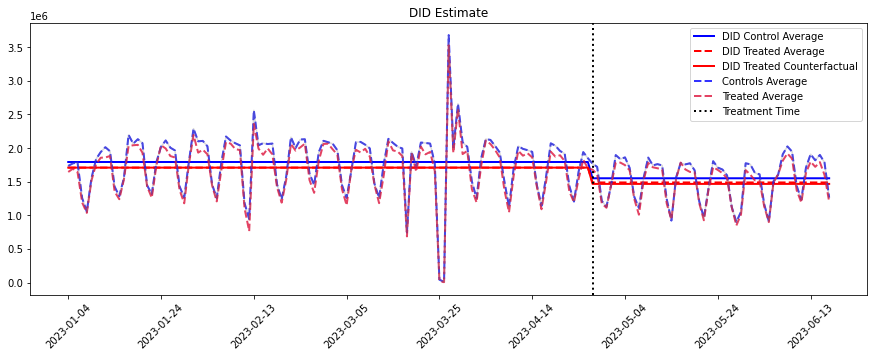

In [34]:
did.plot_2()

# Adobe Dataset 2

In [35]:
data = pd.read_csv('../data/ps_hu_exp.csv')

In [36]:
# drop unused
data = data[data.trt_unit!=-1]

# make wide. Pre-Aggregate. 
data.index = data['date_date']
del data['date_date']

wide = pd.pivot_table(data, columns='date_date', index='trt_unit', values='sales', aggfunc=sum, fill_value=0)
wide=wide[wide.columns[:-1]]

wide.head()


date_date,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,...,2023-06-15,2023-06-16,2023-06-17,2023-06-18,2023-06-19,2023-06-20,2023-06-21,2023-06-22,2023-06-23,2023-06-24
trt_unit,,,,,,,,,,,,,,,,,,,,,
1,688700.6639,1.058459e+06,1.501193e+06,1.645304e+06,1.693825e+06,1.644977e+06,1.190596e+06,1.037025e+06,1.516395e+06,1.762020e+06,...,1.791547e+06,1.600702e+06,1.202196e+06,925243.34590,1.370515e+06,1.721346e+06,1.736914e+06,1.717797e+06,1.653807e+06,987202.27730
500,3849.0700,6.236520e+03,7.088760e+03,8.623270e+03,9.218040e+03,9.287670e+03,7.898040e+03,8.513910e+03,1.214023e+04,1.168506e+04,...,1.067967e+04,1.147771e+04,5.703110e+03,6371.23000,6.208890e+03,8.875560e+03,1.286271e+04,7.724400e+03,1.051731e+04,4503.96000
501,109996.0066,1.828160e+05,2.410301e+05,2.749902e+05,2.889643e+05,3.168295e+05,1.842204e+05,1.521014e+05,2.465144e+05,2.860200e+05,...,2.985433e+05,2.865574e+05,2.165892e+05,159011.31210,2.194017e+05,3.009233e+05,3.032306e+05,3.036898e+05,2.843343e+05,167571.88340
505,19862.0400,2.583488e+04,4.672311e+04,4.252209e+04,3.995638e+04,4.285677e+04,3.009847e+04,2.989465e+04,4.327186e+04,5.457588e+04,...,3.819375e+04,4.000970e+04,3.021208e+04,15788.15018,3.792892e+04,4.679647e+04,5.494358e+04,3.855805e+04,4.471367e+04,30681.27000
506,32179.1100,4.626169e+04,7.605868e+04,7.829410e+04,8.618459e+04,7.983541e+04,6.101569e+04,5.037411e+04,7.110840e+04,8.403398e+04,...,9.606729e+04,8.687347e+04,6.177899e+04,38276.77843,5.733149e+04,7.760033e+04,8.125188e+04,8.652704e+04,7.941183e+04,50530.50578


In [37]:
treated_times = wide.columns[-45:-7]
treated_times = panel_data.TimePeriod(start=treated_times[0], end=treated_times[-1])
treated_units = [1]
pand = panel_data.PanelDataset(wide, treated_times, treated_units)

In [38]:
print(pand.summarize())



        Panel Dataset Summary
        ---------------------
        Number of time points: 175
        Number of units: 39
        Number of treated units: 1
        Treated units: [1]
        Treated periods: [TimePeriod(start='2023-05-11', end='2023-06-17')]
        


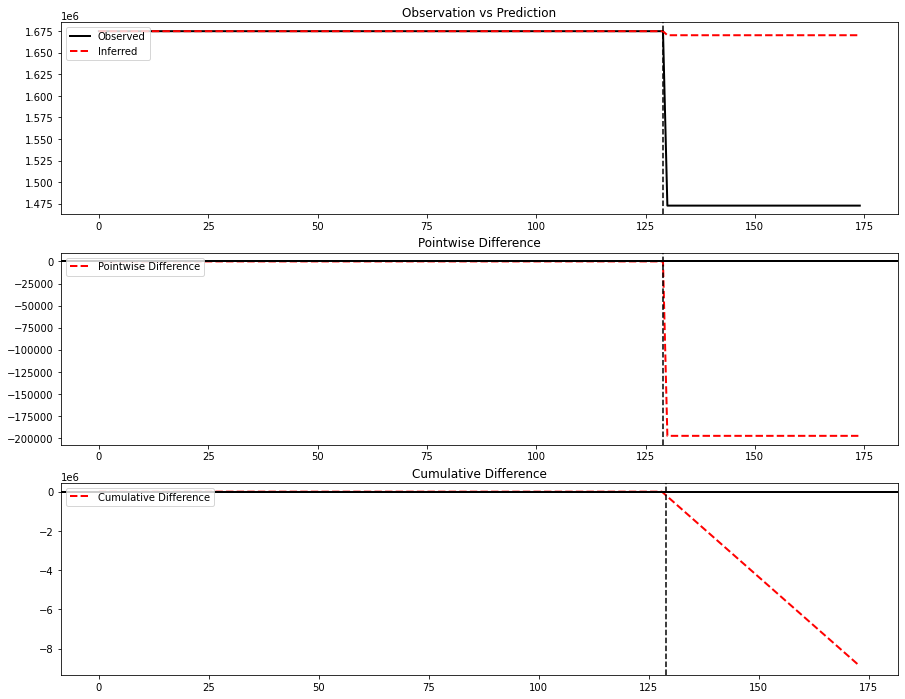

In [39]:
did = DID()
did.run_analysis(pand)
did.plot()

In [40]:
did.summary()

,Average,Cumulative
Actual,1472837.576264,66277690.931893
Predicted,1670303.882979,75163674.734037
,,
Absolute Effect,-197466.306714,-8885983.802145
,,
Relative Effect,-11.822179,-11.822179


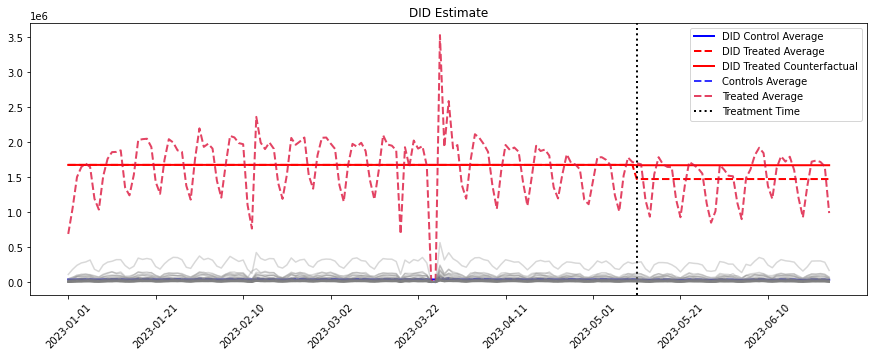

In [41]:
did.plot_2()

In [42]:
#* This returns bad results because the treated units have been summed and control has been left de-aggregated.